# iTunes Songs Dataset – Exploratory Data Analysis (EDA)

## 1. Introduction

The primary objective of this analysis is to:

- Understand the structure and characteristics of the dataset  
- Identify patterns and distributions within key variables  
- Explore relationships between features such as popularity, genre, price and duration  
- Detect potential outliers, missing values, or data inconsistencies  
- Generate initial insights that may guide further statistical or predictive analysis  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


In [50]:
df = pd.read_csv("/Users/vahramdressler/Desktop/YSU/S2/Data Viz/Data-Viz/Data/itunes_music_dataset.csv")
df.shape
df.info()
df.describe()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4915 entries, 0 to 4914
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   track_id           4915 non-null   int64  
 1   track_name         4915 non-null   object 
 2   artist_name        4913 non-null   object 
 3   collection_name    4915 non-null   object 
 4   album_artist       1728 non-null   object 
 5   genre              4915 non-null   object 
 6   rating             4915 non-null   object 
 7   track_price        4540 non-null   float64
 8   collection_price   4539 non-null   float64
 9   release_date       4867 non-null   object 
 10  track_time_millis  4915 non-null   int64  
 11  country            4915 non-null   object 
 12  currency           4915 non-null   object 
 13  preview_url        4914 non-null   object 
 14  artwork_url        4915 non-null   object 
dtypes: float64(2), int64(2), object(11)
memory usage: 576.1+ KB


,track_id,track_name,artist_name,collection_name,album_artist,genre,rating,track_price,collection_price,release_date,track_time_millis,country,currency,preview_url,artwork_url
0,1624932774,POP!,NAYEON,IM NAYEON,NaN,Dance,Clean,1.29,6.99,2022-06-24T12:00:00Z,168107,USA,USD,https://audio-ssl.itunes.apple.com/itunes-asse...,https://is1-ssl.mzstatic.com/image/thumb/Music...
1,1022164261,Riptide,Vance Joy,Dream Your Life Away (Special Edition),NaN,Alternative,Clean,1.29,9.99,2013-03-22T07:00:00Z,202019,USA,USD,https://audio-ssl.itunes.apple.com/itunes-asse...,https://is1-ssl.mzstatic.com/image/thumb/Music...
2,1207120448,Something Just Like This,The Chainsmokers & Coldplay,Memories...Do Not Open,The Chainsmokers,Dance,Clean,1.29,9.99,2017-02-22T08:00:00Z,247165,USA,USD,https://audio-ssl.itunes.apple.com/itunes-asse...,https://is1-ssl.mzstatic.com/image/thumb/Music...
3,1369380479,lovely,Billie Eilish & Khalid,lovely - Single,NaN,Pop,Clean,1.29,1.29,2018-04-19T12:00:00Z,200187,USA,USD,https://audio-ssl.itunes.apple.com/itunes-asse...,https://is1-ssl.mzstatic.com/image/thumb/Music...
4,1450695872,when the party's over,Billie Eilish,"WHEN WE ALL FALL ASLEEP, WHERE DO WE GO?",NaN,Alternative,Clean,1.29,10.99,2018-10-17T07:00:00Z,196077,USA,USD,https://audio-ssl.itunes.apple.com/itunes-asse...,https://is1-ssl.mzstatic.com/image/thumb/Music...


In [51]:
df.isnull().sum()

track_id                0
track_name              0
artist_name             2
collection_name         0
album_artist         3187
genre                   0
rating                  0
track_price           375
collection_price      376
release_date           48
track_time_millis       0
country                 0
currency                0
preview_url             1
artwork_url             0
dtype: int64

Here we can see that there are couple of rows that have missing values in the fields that are important. That is why we will remove the artist names that are null, I will replace the null album to artist name, remove the release date missing and will replace the track price and collection price wihth the median. 

In [52]:
df = df.dropna(subset=['artist_name'])

df = df.dropna(subset=['release_date'])

df['album_artist'] = df['album_artist'].fillna(df['artist_name'])

df['track_price'] = df['track_price'].fillna(df['track_price'].median())
df['collection_price'] = df['collection_price'].fillna(df['collection_price'].median())

df.isnull().sum()

track_id             0
track_name           0
artist_name          0
collection_name      0
album_artist         0
genre                0
rating               0
track_price          0
collection_price     0
release_date         0
track_time_millis    0
country              0
currency             0
preview_url          0
artwork_url          0
dtype: int64

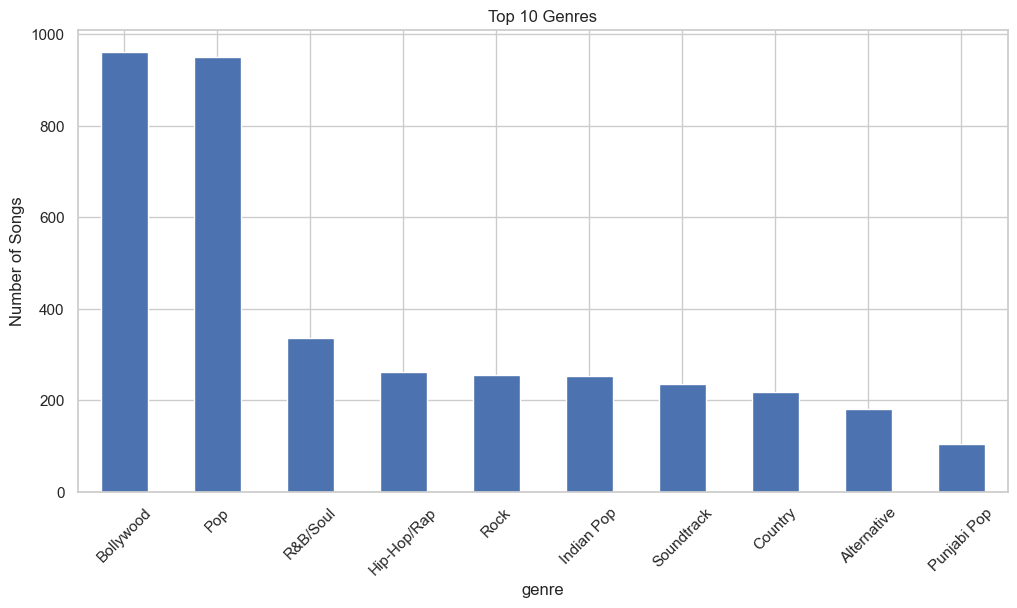

In [53]:

plt.figure(figsize=(12,6))
df['genre'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Genres")
plt.ylabel("Number of Songs")
plt.xticks(rotation=45)
plt.show()

This is a simple check to see how many songs are from each genre and as we can see here, majority of the songs are coming from the Bollywood and Pop. The weight of these 2 genres is almost the half of the all songs in tis dataset which can be explained by the activity of the indian media and ofcourse the most songs nowadays listened is Pop in the western culture. 

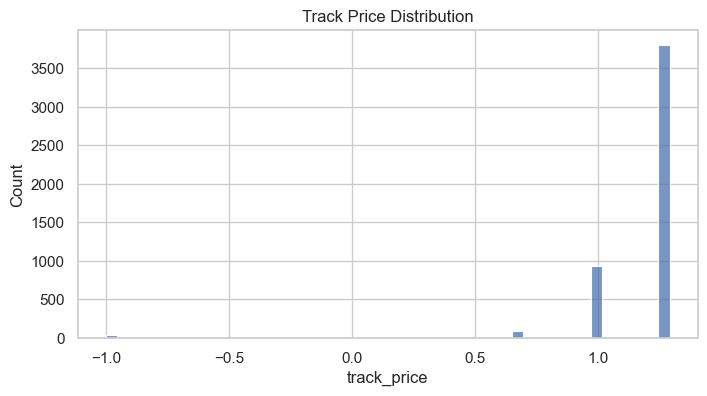

In [54]:
plt.figure(figsize=(8,4))
sns.histplot(df['track_price'], bins=50)
plt.title("Track Price Distribution")
plt.show()

The majority of tracks in the dataset are priced at **$0.99** or **$1.29**, which aligns with common iTunes pricing. However, upon inspecting the data, a few erroneous negative prices were found (e.g., `-1`). These values are clearly incorrect and likely represent data entry errors or artifacts from data collection.

In [55]:
negative_prices = df[df['track_price'] < 0]

negative_prices

,track_id,track_name,artist_name,collection_name,album_artist,genre,rating,track_price,collection_price,release_date,track_time_millis,country,currency,preview_url,artwork_url
16,1411629089,Thunder,Imagine Dragons,Evolve,Imagine Dragons,Alternative,Clean,-1.0,9.99,2017-04-27T07:00:00Z,187145,USA,USD,https://audio-ssl.itunes.apple.com/itunes-asse...,https://is1-ssl.mzstatic.com/image/thumb/Music...
335,1440911729,The Low Spark of High-Heeled Boys,Traffic,The Low Spark of High Heeled Boys (Bonus Track),Traffic,Rock,Clean,-1.0,7.99,1971-11-01T12:00:00Z,701240,USA,USD,https://audio-ssl.itunes.apple.com/itunes-asse...,https://is1-ssl.mzstatic.com/image/thumb/Music...
462,268443200,All Blues,Miles Davis,Kind of Blue,Miles Davis,Jazz,Clean,-1.0,6.99,1959-08-17T07:00:00Z,692897,USA,USD,https://audio-ssl.itunes.apple.com/itunes-asse...,https://is1-ssl.mzstatic.com/image/thumb/Music...
470,1440860872,Theme from Jurassic Park,John Williams,Jurassic Park (20th Anniversary),John Williams,Soundtrack,Clean,-1.0,8.99,1993-05-25T12:00:00Z,205061,USA,USD,https://audio-ssl.itunes.apple.com/itunes-asse...,https://is1-ssl.mzstatic.com/image/thumb/Music...
479,1441520223,Zero,Imagine Dragons,Ralph Breaks the Internet (Original Motion Pic...,Henry Jackman,Soundtrack,Clean,-1.0,11.99,2018-09-19T12:00:00Z,212112,USA,USD,https://audio-ssl.itunes.apple.com/itunes-asse...,https://is1-ssl.mzstatic.com/image/thumb/Music...
882,328449248,I Invented Sex (feat. Drake),Trey Songz,Ready (Deluxe),Trey Songz,R&B/Soul,Clean,-1.0,9.99,2009-08-31T07:00:00Z,247933,USA,USD,https://audio-ssl.itunes.apple.com/itunes-asse...,https://is1-ssl.mzstatic.com/image/thumb/Music...
952,328449508,Successful (with Drake),Trey Songz,Ready (Deluxe),Trey Songz,R&B/Soul,Clean,-1.0,9.99,2009-02-13T08:00:00Z,266253,USA,USD,https://audio-ssl.itunes.apple.com/itunes-asse...,https://is1-ssl.mzstatic.com/image/thumb/Music...
1027,1440837587,I Was Made for Loving You (feat. Ed Sheeran),Tori Kelly,Unbreakable Smile,Tori Kelly,Pop,Clean,-1.0,15.99,2015-06-23T12:00:00Z,188940,USA,USD,https://audio-ssl.itunes.apple.com/itunes-asse...,https://is1-ssl.mzstatic.com/image/thumb/Music...
1219,296790943,Irreplaceable,Beyoncé,B'Day,Beyoncé,Pop,Clean,-1.0,10.99,2006-09-04T07:00:00Z,227613,USA,USD,https://audio-ssl.itunes.apple.com/itunes-asse...,https://is1-ssl.mzstatic.com/image/thumb/Music...
1348,1440661558,Eenie Meenie,Justin Bieber & Sean Kingston,My World 2.0 (Bonus Track Version),Justin Bieber,Pop,Clean,-1.0,9.99,2010-03-19T12:00:00Z,202627,USA,USD,https://audio-ssl.itunes.apple.com/itunes-asse...,https://is1-ssl.mzstatic.com/image/thumb/Music...


As we can see these are the negative values for the prices that is impossible to have. I will replace these values with the median again. 

In [56]:
median_price = df[df['track_price'] > 0]['track_price'].median()

df.loc[df['track_price'] < 0, 'track_price'] = median_price

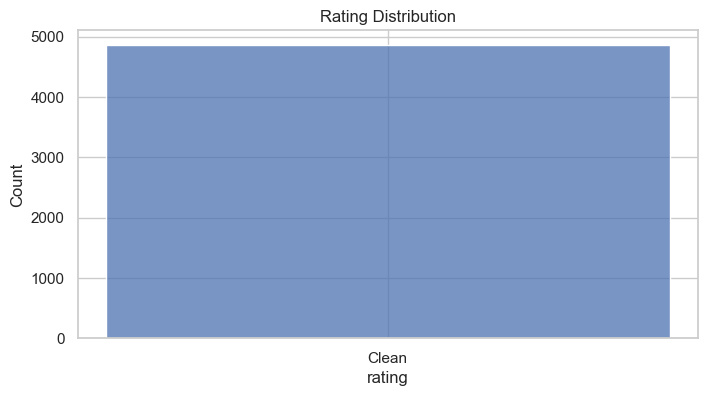

In [57]:
plt.figure(figsize=(8,4))
sns.histplot(df['rating'], bins=10)
plt.title("Rating Distribution")
plt.show()

Only clean rating so nothing to say here. Except maybe it is some kind of an error or wrong input but I can't do anything about that. 

In [71]:
max_index = df['track_time_millis'].idxmax()

df = df.drop(max_index)

df = df.reset_index(drop=True)

df['track_time_millis'].max()

588411

I removed  14 songs that are longer than 10 minutes as they are outliers in the music industry.

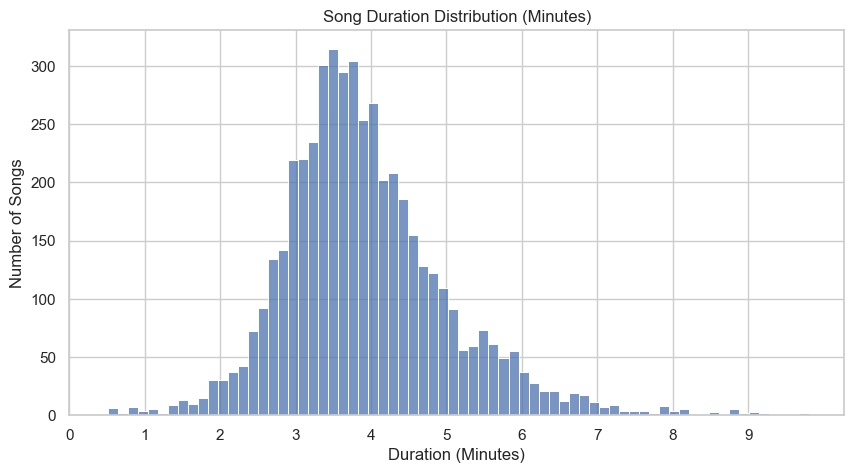

track_id                                                     268443113
track_name                                          Freddie Freeloader
artist_name                                                Miles Davis
collection_name                                           Kind of Blue
album_artist                                               Miles Davis
genre                                                             Jazz
rating                                                           Clean
track_price                                                       1.29
collection_price                                                  6.99
release_date                                      1959-08-17T07:00:00Z
track_time_millis                                               588411
country                                                            USA
currency                                                           USD
preview_url          https://audio-ssl.itunes.apple.com/itunes-asse...
artwor

In [72]:
plt.figure(figsize=(10,5))

sns.histplot(df['track_time_millis']/60000, bins=70)

max_duration = int((df['track_time_millis']/60000).max()) + 1
plt.xticks(np.arange(0, max_duration, 1))

plt.title("Song Duration Distribution (Minutes)")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Songs")
plt.show()

max_index = df['track_time_millis'].idxmax()

longest_song = df.loc[max_index]
longest_song

Now as we can see the most of the songs are from 3 to 4 minutes. This observation could have been done also just by being attentive to the songs that we listen everyday, as most probably they are going to be exactly 3-4 minutes long. 

/var/folders/lr/g5zp64x50sb_wxnpfxzchvvc0000gn/T/ipykernel_15968/1107446913.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_artists.values, y=top_artists.index, palette="viridis")


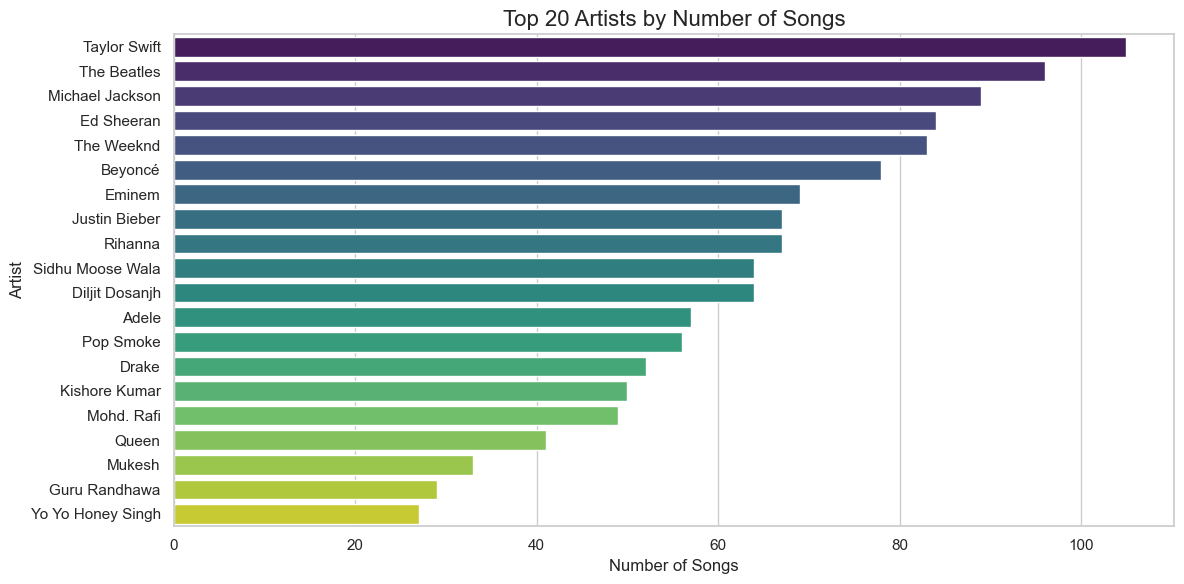

In [75]:
top_artists = df['artist_name'].value_counts().head(20)

plt.figure(figsize=(12,6))
sns.barplot(x=top_artists.values, y=top_artists.index, palette="viridis")
plt.title("Top 20 Artists by Number of Songs", fontsize=16)
plt.xlabel("Number of Songs", fontsize=12)
plt.ylabel("Artist", fontsize=12)
plt.tight_layout()
plt.show()

/var/folders/lr/g5zp64x50sb_wxnpfxzchvvc0000gn/T/ipykernel_15968/217185253.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='genre', y='track_duration_min', data=df_top_genres, palette='coolwarm')


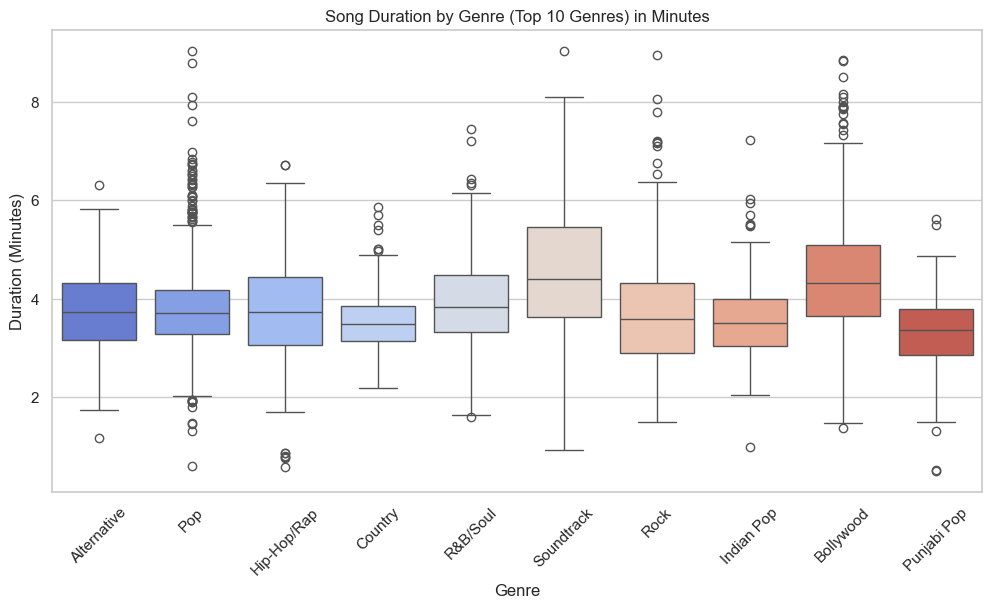

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

df['track_duration_min'] = df['track_time_millis'] / 60000

top_genres = df['genre'].value_counts().head(10).index
df_top_genres = df[df['genre'].isin(top_genres)]

plt.figure(figsize=(12,6))
sns.boxplot(x='genre', y='track_duration_min', data=df_top_genres, palette='coolwarm')
plt.xticks(rotation=45)
plt.title("Song Duration by Genre (Top 10 Genres) in Minutes")
plt.xlabel("Genre")
plt.ylabel("Duration (Minutes)")
plt.show()

Here we can see that soundtracks have a very big interquartile range, which means that they may vary from very short songs to very long ones. The pop and bollywood show a lot of outliers which is normal considered the number of songs that these genres have. In contrast the Punjabi Pop and Country music show more strict time limits. 

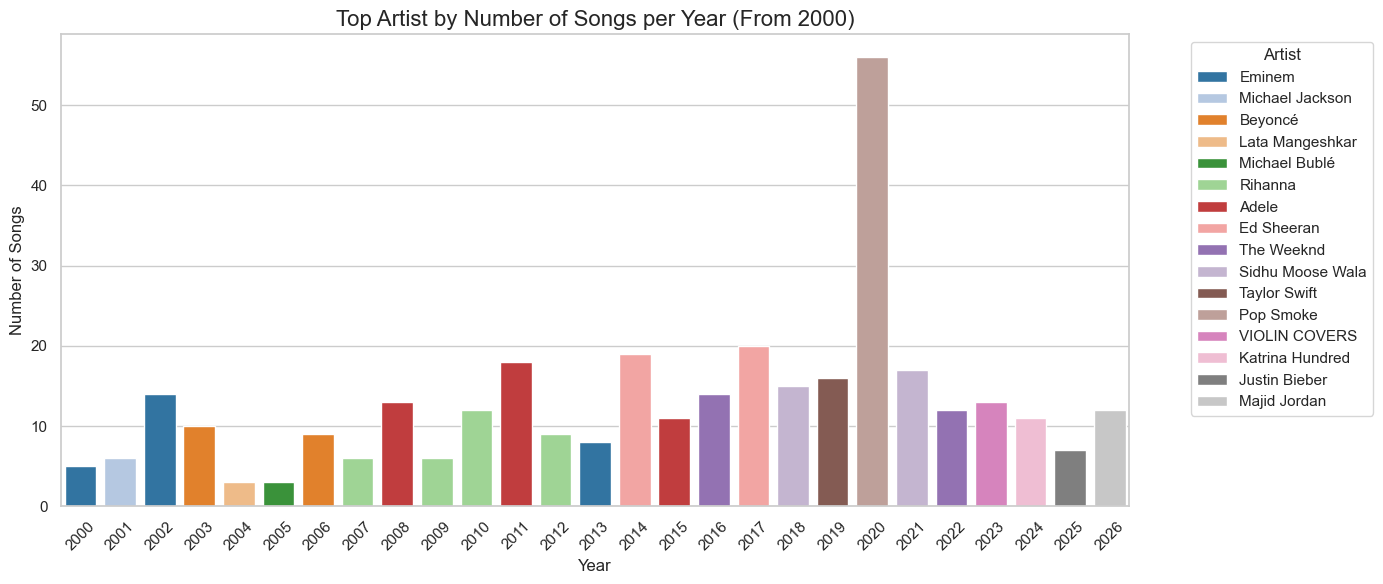

In [82]:
df['release_year'] = pd.to_datetime(df['release_date']).dt.year

df_filtered = df[df['release_year'] >= 2000]

artist_year_counts = df_filtered.groupby(['release_year', 'artist_name']).size().reset_index(name='num_songs')

top_artist_per_year = artist_year_counts.loc[artist_year_counts.groupby('release_year')['num_songs'].idxmax()]

plt.figure(figsize=(14,6))
bars = sns.barplot(
    x='release_year',
    y='num_songs',
    hue='artist_name',
    data=top_artist_per_year,
    dodge=False,
    palette='tab20'
)

plt.title("Top Artist by Number of Songs per Year (From 2000)", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Songs", fontsize=12)
plt.xticks(rotation=45)

handles, labels = bars.get_legend_handles_labels()
plt.legend(handles=handles, labels=labels, title='Artist', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Here we can see that Pop Smoke has more than 50 songs in 2020 which needs to be researched mor in depth as I am not sure that it is possible and I think that may be he was introduced to Itunes in 2020 and every sond that he had in previous years were added to Itunes with date of 2020. 